# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

###  Data Description
You can find the data description here: [Data Dictionary](https://www.nyc.gov/assets/tlc/downloads/pdf/data_dictionary_trip_records_yellow.pdf)

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [ ]:
# Import warnings



In [87]:
# Import the libraries you will be using for analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 2.4.2
pandas version: 3.0.1
matplotlib version: 3.10.8
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [36]:
# Try loading one file

df = pd.read_parquet('datasets/2023-12.parquet')
df.info()

# Output:
# Index: 3041714 entries, 0 to 0
# Data columns (total 19 columns)

<class 'pandas.DataFrame'>
Index: 3333925 entries, 0 to 0
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee            float64       
dtypes

In [37]:
print(df['tpep_pickup_datetime'])

0   2023-12-01 00:06:06
0   2023-12-01 00:22:26
0   2023-12-01 00:59:44
0   2023-12-01 00:22:17
0   2023-12-01 00:18:16
            ...        
0   2023-12-31 23:04:34
0   2023-12-31 23:08:15
0   2023-12-31 23:16:15
0   2023-12-31 23:21:58
0   2023-12-31 23:10:47
Name: tpep_pickup_datetime, Length: 3333925, dtype: datetime64[us]


How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

#### Please Note:
#### I am using my local Jupyter Notebook and all data files are uploaded into 'datasets' directory locally !

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [5]:
import os
from datetime import datetime

folder_path = "Datasets-Dictionary-NYC/trip_records"

file_list = sorted([
    f for f in os.listdir(folder_path)
    if os.path.isfile(os.path.join(folder_path, f))
], key=lambda x: int(x.split('-')[1].split('.')[0]))

print(file_list)

##############
# Output:
##############
# ['2023-1.parquet', '2023-2.parquet', '2023-3.parquet', '2023-4.parquet', '2023-5.parquet', '2023-6.parquet', 
#'2023-7.parquet', '2023-8.parquet', '2023-9.parquet', '2023-10.parquet', '2023-11.parquet', '2023-12.parquet']

['2023-1.parquet', '2023-2.parquet', '2023-3.parquet', '2023-4.parquet', '2023-5.parquet', '2023-6.parquet', '2023-7.parquet', '2023-8.parquet', '2023-9.parquet', '2023-10.parquet', '2023-11.parquet', '2023-12.parquet']


#### As the data is huge, just keeping 1% of sample data instead of 5 %
#### Total Combined Rows: 379268

In [6]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# initialise an empty dataframe
combined_df = pd.DataFrame()

# Start time
start_time = datetime.now()
print("Process Started :", start_time)

# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        
        df = pd.read_parquet(f"{folder_path}/{file_name}")
    
        year, month = file_name.replace('.parquet', '').split('-')
        if int(month) >= 1 and int(month) <= 9:
            month = month.zfill(2)
        filtered_month = f'{year}-{month}'
        
        # Filter only matching records as per file name, Exclude any records any other year like 2022 
        df = df[ df['tpep_pickup_datetime'].dt.strftime('%Y-%m') == filtered_month ]
    
        # Iterate through each day
        for day in df['tpep_pickup_datetime'].dt.date.unique():
            day_df = df[ df['tpep_pickup_datetime'].dt.date == day ] 
            
            # Iterate through each hour of that day
            for hour in day_df['tpep_pickup_datetime'].dt.hour.unique():
                hour_df = day_df[day_df['tpep_pickup_datetime'].dt.hour == hour]
                
                # Sample 5% of the data
                sampled_hour_df = hour_df.sample(frac=0.01, random_state=42)

                # Concatenate directly
                combined_df = pd.concat([combined_df, sampled_hour_df], ignore_index=True)

            print(
                f"File Name : {file_name} | "
                f"File Rows : {len(df)} | "
                f"Daily Rows : {len(day_df)} | "
                f"Sampled Rows (1%) : {len(sampled_hour_df)} | "
                f"Total Combined Rows : {len(combined_df)}"
            )
            
    except Exception as e:
        print(f"Error reading file {file_name}: {e}")
        
# End time
end_time = datetime.now()
print("Process Ended   :", end_time)
# Total time taken
print("Time Taken      :", end_time - start_time)
print(combined_df.info())

Process Started : 2026-05-14 10:27:52.992577
File Name : 2023-1.parquet | File Rows : 3041666 | Daily Rows : 76021 | Sampled Rows (1%) : 26 | Total Combined Rows : 762
File Name : 2023-1.parquet | File Rows : 3041666 | Daily Rows : 65090 | Sampled Rows (1%) : 18 | Total Combined Rows : 1413
File Name : 2023-1.parquet | File Rows : 3041666 | Daily Rows : 85011 | Sampled Rows (1%) : 28 | Total Combined Rows : 2263
File Name : 2023-1.parquet | File Rows : 3041666 | Daily Rows : 94290 | Sampled Rows (1%) : 37 | Total Combined Rows : 3206
File Name : 2023-1.parquet | File Rows : 3041666 | Daily Rows : 100269 | Sampled Rows (1%) : 54 | Total Combined Rows : 4210
File Name : 2023-1.parquet | File Rows : 3041666 | Daily Rows : 101727 | Sampled Rows (1%) : 57 | Total Combined Rows : 5231
File Name : 2023-1.parquet | File Rows : 3041666 | Daily Rows : 104114 | Sampled Rows (1%) : 57 | Total Combined Rows : 6272
File Name : 2023-1.parquet | File Rows : 3041666 | Daily Rows : 84337 | Sampled Rows 

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [88]:
output_folder = 'pqt_output'
# Store the df in parquet format using compression, ignore saving index
combined_df.to_parquet(
    f'{output_folder}/combined_sample_data.parquet',
    compression='snappy',
    index=False
)

NameError: name 'combined_df' is not defined

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [89]:
# Load the new data file

df = pd.read_parquet(f'{output_folder}/combined_sample_data.parquet')

In [90]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,Airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,32.40,6.0,0.5,0.00,0.0,1.0,41.15,0.0,1.25,NaN
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,7.90,1.0,0.5,2.58,0.0,1.0,15.48,2.5,0.00,NaN
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,11.40,1.0,0.5,0.00,0.0,1.0,16.40,2.5,0.00,NaN
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,6.50,1.0,0.5,0.00,0.0,1.0,11.50,2.5,0.00,NaN
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,25.64,0.0,0.5,5.93,0.0,1.0,35.57,NaN,NaN,NaN


In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 379268 entries, 0 to 379267
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               379268 non-null  int64         
 1   tpep_pickup_datetime   379268 non-null  datetime64[us]
 2   tpep_dropoff_datetime  379268 non-null  datetime64[us]
 3   passenger_count        366326 non-null  float64       
 4   trip_distance          379268 non-null  float64       
 5   RatecodeID             366326 non-null  float64       
 6   store_and_fwd_flag     366326 non-null  object        
 7   PULocationID           379268 non-null  int64         
 8   DOLocationID           379268 non-null  int64         
 9   payment_type           379268 non-null  int64         
 10  fare_amount            379268 non-null  float64       
 11  extra                  379268 non-null  float64       
 12  mta_tax                379268 non-null  float64       


#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [97]:
# Fix the index and drop any columns that are not needed

# Drop the columns having more than 50% missing values
df.isnull().mean() * 100

# airport_fee  column has 92.176245 % missng values which could be dropped

VendorID                  0.000000
tpep_pickup_datetime      0.000000
tpep_dropoff_datetime     0.000000
passenger_count           3.412363
trip_distance             0.000000
RatecodeID                3.412363
store_and_fwd_flag        3.412363
PULocationID              0.000000
DOLocationID              0.000000
payment_type              0.000000
fare_amount               0.000000
extra                     0.000000
mta_tax                   0.000000
tip_amount                0.000000
tolls_amount              0.000000
improvement_surcharge     0.000000
total_amount              0.000000
congestion_surcharge      3.412363
airport_fee              92.176245
Airport_fee              11.236118
dtype: float64

In [98]:
# Columns having only one unique value are useless for analysis/modeling.
df.nunique()

# VendorID                      3
# store_and_fwd_flag            2
# congestion_surcharge          3
# improvement_surcharge         4

VendorID                      3
tpep_pickup_datetime     376266
tpep_dropoff_datetime    376273
passenger_count              10
trip_distance              3078
RatecodeID                    6
store_and_fwd_flag            2
PULocationID                245
DOLocationID                258
payment_type                  5
fare_amount                4507
extra                        41
mta_tax                       6
tip_amount                 2773
tolls_amount                338
improvement_surcharge         4
total_amount              10035
congestion_surcharge          3
airport_fee                   2
Airport_fee                   4
dtype: int64

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [99]:
# Combine the two airport fee columns
df['Airport_fee'] = df['Airport_fee'].fillna(df['airport_fee'])

# Count missing (NaN) values in Airport_fee
print(df['Airport_fee'].isna().sum())

df['Airport_fee'] = df['Airport_fee'].fillna(0)

12942


In [100]:
# Drop other airport_fee column
df.drop(columns=['airport_fee'], inplace=True)

In [101]:
# Fix the index now
df.reset_index(drop=True)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,32.40,6.0,0.5,0.00,0.00,1.0,41.15,0.0,1.25
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,7.90,1.0,0.5,2.58,0.00,1.0,15.48,2.5,0.00
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,11.40,1.0,0.5,0.00,0.00,1.0,16.40,2.5,0.00
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,6.50,1.0,0.5,0.00,0.00,1.0,11.50,2.5,0.00
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,25.64,0.0,0.5,5.93,0.00,1.0,35.57,NaN,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
379263,2,2023-12-31 23:12:51,2023-12-31 23:38:25,1.0,4.03,1.0,N,236,68,2,25.40,1.0,0.5,0.00,0.00,1.0,30.40,2.5,0.00
379264,2,2023-12-31 23:23:33,2024-01-01 00:02:05,1.0,21.72,2.0,N,132,48,1,70.00,0.0,0.5,8.00,6.94,1.0,88.94,2.5,0.00
379265,2,2023-12-31 23:26:18,2023-12-31 23:28:01,2.0,0.29,1.0,N,211,211,1,4.40,1.0,0.5,1.00,0.00,1.0,10.40,2.5,0.00
379266,2,2023-12-31 23:48:46,2023-12-31 23:56:23,1.0,1.33,1.0,N,68,234,1,9.30,1.0,0.5,2.86,0.00,1.0,17.16,2.5,0.00


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [102]:
# check where values of fare amount are negative

print(df[ df['fare_amount'] < 0 ] )

# Could not find values of fare amount as negative 

Empty DataFrame
Columns: [VendorID, tpep_pickup_datetime, tpep_dropoff_datetime, passenger_count, trip_distance, RatecodeID, store_and_fwd_flag, PULocationID, DOLocationID, payment_type, fare_amount, extra, mta_tax, tip_amount, tolls_amount, improvement_surcharge, total_amount, congestion_surcharge, Airport_fee]
Index: []


Did you notice something different in the `RatecodeID` column for above records?

In [179]:
# Analyse RatecodeID for the negative fare amounts

# Could not find values of fare amount as negative 

In [103]:
# Find which columns have negative values

neg_fields = []
for c in df.select_dtypes(include=['int64', 'float64']).columns:
    if (df[c] < 0).any():
        neg_fields.append(c)

print(neg_fields)

['extra', 'mta_tax', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


In [104]:
# fix these negative values

df['extra'] = df['extra'].abs()
df['mta_tax'] = df['mta_tax'].abs()
df['total_amount'] = df['total_amount'].abs()
df['congestion_surcharge'] = df['congestion_surcharge'].abs()
df['improvement_surcharge'] = df['improvement_surcharge'].abs()
df['Airport_fee'] = df['Airport_fee'].abs()

### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [105]:
# Find the proportion of missing values in each column

df.isnull().mean() * 100

VendorID                 0.000000
tpep_pickup_datetime     0.000000
tpep_dropoff_datetime    0.000000
passenger_count          3.412363
trip_distance            0.000000
RatecodeID               3.412363
store_and_fwd_flag       3.412363
PULocationID             0.000000
DOLocationID             0.000000
payment_type             0.000000
fare_amount              0.000000
extra                    0.000000
mta_tax                  0.000000
tip_amount               0.000000
tolls_amount             0.000000
improvement_surcharge    0.000000
total_amount             0.000000
congestion_surcharge     3.412363
Airport_fee              0.000000
dtype: float64

**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [106]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'

null_rows = df[ df['passenger_count'].isnull() ]
print(len(null_rows))

df['passenger_count'] = df['passenger_count'].fillna(0)

12942


Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [107]:
# Fix missing values in 'RatecodeID'

rcodeid_rows = df[ df['RatecodeID'].isnull() ]
print(len(rcodeid_rows))

df['RatecodeID'] = df['RatecodeID'].fillna(1)

12942


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [108]:
# handle null values in congestion_surcharge

cong_charge_rows = df[ df['congestion_surcharge'].isnull() ]
print(len(cong_charge_rows))

df['congestion_surcharge'] = df['congestion_surcharge'].fillna(0)

12942


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [109]:
# Handle any remaining missing values

missing_cols = df.columns[ df.isnull().any() ].tolist()

print(missing_cols)

# Found these fields: ['store_and_fwd_flag', 'Airport_fee']

# N = not a store and forward trip
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna('N')

# Replaced with 0, no Airport Fee
df['Airport_fee'] = df['Airport_fee'].fillna(0)

['store_and_fwd_flag']


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [110]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns
# Get the columns having outliers for Numeric fields

outlier_cols = []
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for c in num_cols:

    Q1 = df[c].quantile(0.25)
    Q3 = df[c].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (
            (df[c] < lower_bound) |
            (df[c] > upper_bound)
        )
    ).sum()

    if outlier_count > 0:
        outlier_cols.append(c)

print(outlier_cols)

# Output:
# --------------------
# ['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 
# 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']

['VendorID', 'passenger_count', 'trip_distance', 'RatecodeID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ payment_type counts as there are very less instances.

In [111]:
# remove payment_type > 6

df = df.reset_index(drop=True)

In [113]:
# Continue with outlier handling

# Let's find out trips having trip_distance > 250

trip250_df = df[
    (df['trip_distance'] > 250)
].copy()

# Calculate trip duration in minutes
trip250_df['trip_duration_mins'] = (
    (
        trip250_df['tpep_dropoff_datetime'] -
        trip250_df['tpep_pickup_datetime']
    ).dt.total_seconds() / 60
)

# Display important columns
trip250_df[
    [
        'tpep_pickup_datetime',
        'tpep_dropoff_datetime',
        'trip_distance',
        'fare_amount',
        'total_amount',
        'Airport_fee',
        'PULocationID',
        'DOLocationID',
        'trip_duration_mins'
    ]
]

# Before removing these records, let's also check fare_amount along with trip_distance
print(len(df[ (df['trip_distance'] > 250)  & (df['fare_amount'] < 100) ]))

# Before removing these records, let's also check trip_distance along with trip_duration_mins
print(len(trip250_df[ (trip250_df['trip_distance'] > 250)  & (trip250_df['trip_duration_mins'] < 60) ]))


# Keep only valid trip_distance values
df = df[ ~(df['trip_distance'] > 250)  & (df['fare_amount'] < 100) ]

# Retain rows from df that are NOT present in trip250_df

df = df[ ~df.index.isin(trip250_df.index) ]
df = df.reset_index(drop=True)

0
0


In [114]:
# Entries where trip_distance is nearly 0 and fare_amount is more than 300
trips_distance_0 = df[
    (df['trip_distance'] < 1) &
    (df['fare_amount'] > 300)
]

print(trips_distance_0[
    [
        'tpep_pickup_datetime',
        'tpep_dropoff_datetime',
        'trip_distance',
        'fare_amount',
        'total_amount',
        'Airport_fee'
    ]
])

# Keep only valid trip_distance values
df = df[ ~(df['trip_distance'] > 250)  & (df['fare_amount'] < 100) ]

# Retain rows from df that are NOT present in trips_distance_0

df = df[ ~df.index.isin(trips_distance_0.index) ]
df = df.reset_index(drop=True)

Empty DataFrame
Columns: [tpep_pickup_datetime, tpep_dropoff_datetime, trip_distance, fare_amount, total_amount, Airport_fee]
Index: []


In [115]:
# Entries where trip_distance and fare_amount are 0 but the pickup and dropoff zones are different

diff_zones_df = df[
    (df['trip_distance'] == 0) &
    (df['fare_amount'] == 0) &
    (df['PULocationID'] != df['DOLocationID'])
]

print(len(diff_zones_df[
    [
        'PULocationID',
        'DOLocationID',
        'tpep_pickup_datetime',
        'tpep_dropoff_datetime',
        'trip_distance',
        'fare_amount',
        'total_amount',
        'Airport_fee'
    ]
]))

# Retain rows from df that are NOT present in diff_zones_df
df = df[ ~df.index.isin(diff_zones_df.index) ]
df = df.reset_index(drop=True)

9


In [116]:
# Valid values for payment_type: 1= Credit card, 2= Cash, 3= No charge, 4= Dispute, 5= Unknown, 6= Voided trip

# Keep only valid payment_type values from 1 to 6
df = df[ df['payment_type'].isin([1, 2, 3, 4, 5, 6]) ]
df['payment_type'].unique()

array([2, 1, 4, 3])

In [117]:
# Find RatecodeID values
print(df['RatecodeID'].unique())

# Valid values for RatecodeID: 1= Standard rate, 2=JFK, 3=Newark, 4=Nassau or Westchester, 5=Negotiated fare, 6=Group ride

# Count INVALID RatecodeID rows 
invalid_rows_cnt = (~df['RatecodeID'].isin([1, 2, 3, 4, 5, 6]))
print(invalid_rows_cnt.sum())
      
# Keep only valid RatecodeID values
df = df[ df['RatecodeID'].isin([1, 2, 3, 4, 5, 6]) ]

[ 1.  2.  5.  3. 99.  4.]
2130


In [118]:
# Check for tip_amount is negative or very high and more than fare_amount

print(df[ (df['tip_amount'] < 0) | (df['tip_amount'] > 100) & (df['fare_amount'] < df['tip_amount']) ])

# For negative cap it to 0 and for higher value than 100 keep to 10% of fare amount
df.loc[df['tip_amount'] < 0, 'tip_amount'] = 0
df.loc[ (df['tip_amount'] > 100) & (df['fare_amount'] < df['tip_amount']), 'tip_amount'] = df['fare_amount']*0.1

        VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
167648         1  2023-06-07 13:58:40   2023-06-07 14:05:58              1.0   
199084         1  2023-07-09 12:08:25   2023-07-09 12:39:10              3.0   
257046         1  2023-09-09 01:04:43   2023-09-09 01:28:40              3.0   

        trip_distance  RatecodeID store_and_fwd_flag  PULocationID  \
167648            1.5         1.0                  N            13   
199084           10.3         5.0                  N           231   
257046            4.6         1.0                  N            79   

        DOLocationID  payment_type  fare_amount  extra  mta_tax  tip_amount  \
167648            87             1         10.0    2.5      0.5      150.29   
199084           265             1          0.0    0.0      0.0      115.00   
257046            80             1         26.1    3.5      0.5      150.00   

        tolls_amount  improvement_surcharge  total_amount  \
167648          0.00

In [119]:
# Check for tolls_amount is negative or very high and more than fare_amount

print(df[ (df['tolls_amount'] < 0) | (df['tolls_amount'] > 100) & (df['fare_amount'] < df['tolls_amount']) ])

# For negative cap it to 0 and for high value keep to 100
df.loc[df['tolls_amount'] < 0, 'tolls_amount'] = 0
df.loc[(df['tolls_amount'] > 100) & (df['fare_amount'] < df['tolls_amount']), 'tolls_amount'] = 100

        VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
115377         1  2023-04-20 18:45:45   2023-04-20 18:46:08              1.0   

        trip_distance  RatecodeID store_and_fwd_flag  PULocationID  \
115377            0.0         1.0                  Y           265   

        DOLocationID  payment_type  fare_amount  extra  mta_tax  tip_amount  \
115377           265             1          3.0    2.5      0.5         5.0   

        tolls_amount  improvement_surcharge  total_amount  \
115377         143.0                    1.0         155.0   

        congestion_surcharge  Airport_fee  
115377                   0.0          0.0  


In [120]:
# improvement_surcharge value is usually 0.3
# Check for improvement_surcharge is negative or very high > 10

print(df['improvement_surcharge'].value_counts())
print(df[ (df['improvement_surcharge'] < 0) | (df['improvement_surcharge'] > 10) ])

# For negative cap it to 0 and for high value keep to 100
df.loc[df['improvement_surcharge'] < 0, 'improvement_surcharge'] = 0
df.loc[(df['improvement_surcharge'] > 10), 'improvement_surcharge'] = 0.3

improvement_surcharge
1.0    362676
0.3       152
0.0       120
Name: count, dtype: int64
Empty DataFrame
Columns: [VendorID, tpep_pickup_datetime, tpep_dropoff_datetime, passenger_count, trip_distance, RatecodeID, store_and_fwd_flag, PULocationID, DOLocationID, payment_type, fare_amount, extra, mta_tax, tip_amount, tolls_amount, improvement_surcharge, total_amount, congestion_surcharge, Airport_fee]
Index: []


In [121]:
# congestion_surcharge value is usually 2.5
# Check for congestion_surcharge is negative or very high > 10

print(df['congestion_surcharge'].value_counts())
print(df[ (df['congestion_surcharge'] < 0) | (df['congestion_surcharge'] > 10) ])

# For negative cap it to 0 and for high value keep to 2.5
df.loc[df['congestion_surcharge'] < 0, 'congestion_surcharge'] = 0
df.loc[(df['congestion_surcharge'] > 10), 'congestion_surcharge'] = 2.5

congestion_surcharge
2.5    338168
0.0     24780
Name: count, dtype: int64
Empty DataFrame
Columns: [VendorID, tpep_pickup_datetime, tpep_dropoff_datetime, passenger_count, trip_distance, RatecodeID, store_and_fwd_flag, PULocationID, DOLocationID, payment_type, fare_amount, extra, mta_tax, tip_amount, tolls_amount, improvement_surcharge, total_amount, congestion_surcharge, Airport_fee]
Index: []


In [122]:
# total_amount value is usually 2.5
# Check for total_amount is negative or very high value > 1000

# print(df['total_amount'].value_counts())
print(df[ (df['total_amount'] < 0) | (df['total_amount'] > 1000) ])

# High total_amount = 100 and tiny distance < 1 mile
print(len(df[ (df['total_amount'] > 100) & (df['trip_distance'] <= 1) ]))

# Let's keep to the mean of total_amount where trip_distance < 1
trip_dist_1_mean = (df[df['trip_distance'] <= 1]['total_amount'].mean().round(2))
df.loc[(df['total_amount'] > 100) & (df['trip_distance'] <= 1), 'total_amount'] = trip_dist_1_mean

# High total but short duration
df['trip_duration_mins'] = (
    (
        df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
    ).dt.total_seconds() / 60
)

print( len(df[ (df['total_amount'] > 100) & (df['trip_duration_mins'] <= 10) ]) )

trip_dur_1_mean = (df[df['trip_duration_mins'] <= 10]['total_amount'].mean().round(2))
df.loc[(df['total_amount'] > 100) & (df['trip_duration_mins'] <= 10), 'total_amount'] = trip_dist_1_mean

Empty DataFrame
Columns: [VendorID, tpep_pickup_datetime, tpep_dropoff_datetime, passenger_count, trip_distance, RatecodeID, store_and_fwd_flag, PULocationID, DOLocationID, payment_type, fare_amount, extra, mta_tax, tip_amount, tolls_amount, improvement_surcharge, total_amount, congestion_surcharge, Airport_fee]
Index: []
245
19


In [123]:
# Check for Airport_fee is negative or very high and more than fare_amount
print(df[ (df['Airport_fee'] < 0) | (df['Airport_fee'] > 100) & (df['fare_amount'] < df['Airport_fee']) ])

# Airport fee but tiny fare
print(len(df[(df['Airport_fee'] > 0) & (df['fare_amount'] < 5)]))
# Set to NO Airport fee i.e. Airport_fee = 0
df.loc[(df['Airport_fee'] > 0) & (df['fare_amount'] < 5), 'Airport_fee'] = 0

# Airport fee with zero distance
print(len(df[ (df['Airport_fee'] > 0) & (df['trip_distance'] == 0) ]))
# Set to NO Airport fee i.e. Airport_fee = 0
df.loc[(df['Airport_fee'] > 0) & (df['trip_distance'] == 0), 'Airport_fee'] = 0

Empty DataFrame
Columns: [VendorID, tpep_pickup_datetime, tpep_dropoff_datetime, passenger_count, trip_distance, RatecodeID, store_and_fwd_flag, PULocationID, DOLocationID, payment_type, fare_amount, extra, mta_tax, tip_amount, tolls_amount, improvement_surcharge, total_amount, congestion_surcharge, Airport_fee, trip_duration_mins]
Index: []
274
240


In [124]:
# Do any columns need standardising?

# Check unique values in store_and_fwd_flag
# Verify if distinct values have consistent upper/lower case
df['store_and_fwd_flag'].unique()
# Output: array(['N', 'Y'], dtype=object) - NO INVALID VALUES FOUND, Nothing to correct.

array(['N', 'Y'], dtype=object)

## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [ ]:
df.columns.tolist()

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

| Column Name            | Classification | Remarks |
|------------------------|---------------|---------|
| VendorID               | Categorical | It has got only 2 unique values |
| tpep_pickup_datetime   | Datetime Type | Neither Numerical nor Categorical |
| tpep_dropoff_datetime  | Datetime Type | Neither Numerical nor Categorical |
| passenger_count        | Numerical |  |
| trip_distance          | Numerical |  |
| RatecodeID             | Categorical | It has got only 6 unique values |
| store_and_fwd_flag     | Categorical | Y or N |
| PULocationID           | Categorical | Though values are numerical, only around 250–260 distinct values |
| DOLocationID           | Categorical | Though values are numerical, only around 250–260 distinct values |
| payment_type           | Categorical | It has got only 6 unique values |
| fare_amount            | Numerical |  |
| extra                  | Numerical |  |
| mta_tax                | Numerical |  |
| tip_amount             | Numerical |  |
| tolls_amount           | Numerical |  |
| improvement_surcharge  | Numerical |  |
| total_amount           | Numerical |  |
| congestion_surcharge   | Numerical |  |
| Airport_fee            | Numerical |  |

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

    tpep_pickup_hour  pickup_count
0                  0         10196
1                  1          6802
2                  2          4482
3                  3          2910
4                  4          1837
5                  5          1866
6                  6          4685
7                  7          9613
8                  8         13448
9                  9         15404
10                10         16899
11                11         18367
12                12         19956
13                13         20630
14                14         22101
15                15         22677
16                16         22652
17                17         24588
18                18         25720
19                19         23080
20                20         20631
21                21         20548
22                22         18963
23                23         14893


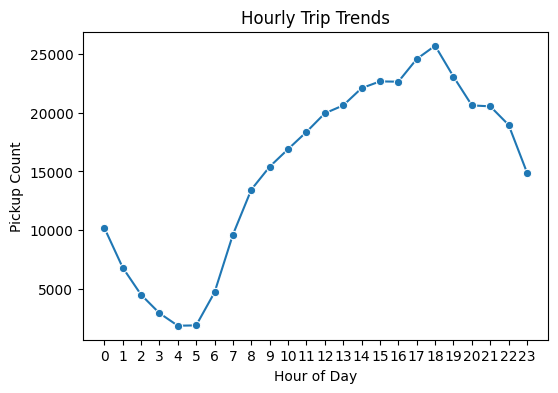

In [181]:
# Find and show the hourly trends in taxi pickups
df['tpep_pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
hourly_trends = (df.groupby('tpep_pickup_hour').size().reset_index(name='pickup_count')).sort_values('tpep_pickup_hour')
print(hourly_trends)

# Plot
plt.figure(figsize=(6,4))

sns.lineplot(
    data=hourly_trends,
    x='tpep_pickup_hour',
    y='pickup_count',
    marker='o'
)

plt.title('Hourly Trip Trends')
plt.xlabel('Hour of Day')
plt.ylabel('Pickup Count')
plt.xticks(range(24))

plt.show()

  tpep_pickup_day  pickup_count
1          Monday         45256
5         Tuesday         52640
6       Wednesday         55748
4        Thursday         56956
0          Friday         53759
2        Saturday         52851
3          Sunday         45738


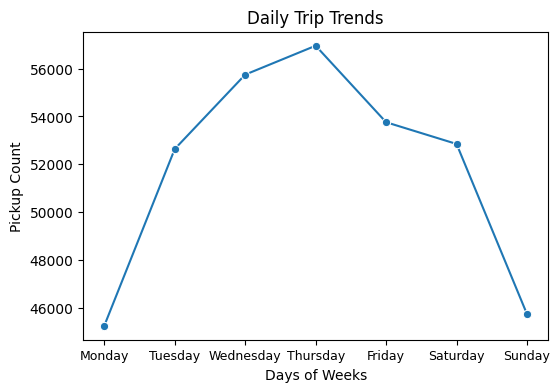

In [196]:
days_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

# Find and show the daily trends in taxi pickups (days of the week)
df['tpep_pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()
# Convert to categorical with proper order
daily_trends['tpep_pickup_day'] = pd.Categorical(
    daily_trends['tpep_pickup_day'],
    categories=days_order,
    ordered=True
)

# Sort dataframe
daily_trends = daily_trends.sort_values(
    'tpep_pickup_day'
)
print(daily_trends)

# Plot
plt.figure(figsize=(6,4))

sns.lineplot(
    data=daily_trends,
    x='tpep_pickup_day',
    y='pickup_count',
    marker='o'
)

plt.title('Daily Trip Trends')
plt.xlabel('Days of Weeks')
plt.ylabel('Pickup Count')
plt.xticks(range(7), fontsize=9)

plt.show()

   tpep_pickup_month  pickup_count
4            January         29474
3           February         27953
7              March         32550
0              April         31401
8                May         33490
6               June         31527
5               July         27705
1             August         26744
11         September         26506
10           October         33053
9           November         31361
2           December         31184


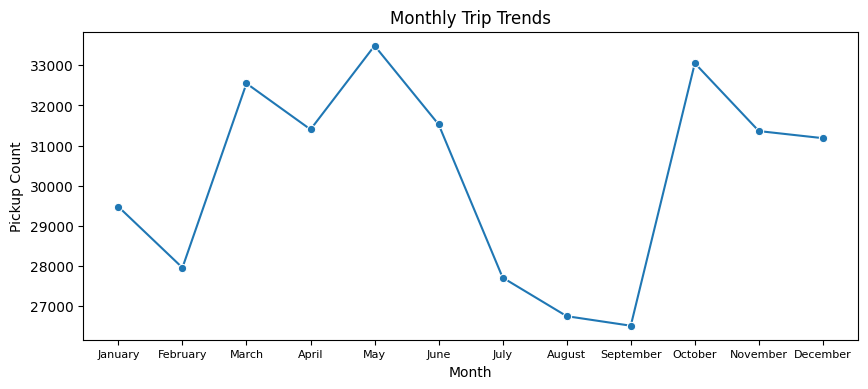

In [198]:
# Show the monthly trends in pickups

month_order = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]

df['tpep_pickup_month'] = df['tpep_pickup_datetime'].dt.month_name()
monthly_trends = (df.groupby('tpep_pickup_month').size().reset_index(name='pickup_count')).sort_values('pickup_count')
# Convert to categorical with proper order
monthly_trends['tpep_pickup_month'] = pd.Categorical(
    monthly_trends['tpep_pickup_month'],
    categories=month_order,
    ordered=True
)

# Sort dataframe
monthly_trends = monthly_trends.sort_values(
    'tpep_pickup_month'
)
print(monthly_trends)

# Plot
plt.figure(figsize=(10,4))

sns.lineplot(
    data=monthly_trends,
    x='tpep_pickup_month',
    y='pickup_count',
    marker='o'
)

plt.title('Monthly Trip Trends')
plt.xlabel('Month')
plt.ylabel('Pickup Count')
plt.xticks(range(12), fontsize=8)

plt.show()

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [240]:
# Analyse the above parameters

lst = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']

for ele in lst:
    cnt = (df[ele] < 0).sum()
    if cnt > 0:
        print(f"Negative values found in {ele}: {cnt}")

# Output: 
# Negative values found in total_amount: 15

for ele in lst:
    cnt = (df[ele] == 0).sum()
    if cnt > 0:
        print(f"Zero values found in {ele}: {cnt}")

# Output:
# Zero values found in fare_amount: 115
# Zero values found in tip_amount: 79136
# Zero values found in total_amount: 45
# Zero values found in trip_distance: 4145

Zero values found in fare_amount: 115
Zero values found in tip_amount: 79136
Zero values found in total_amount: 45
Zero values found in trip_distance: 4145


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

<span style="color:blue">Yes, for the records where NO valid or required trip data is found, we could filter out such records and make a copy of non-zero records.</span>

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [241]:
# Create a df with non zero entries for the selected parameters.

cols = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']
non_zero_df = df[ (df[cols] != 0).any(axis=1) ].copy()

print(f"Actual Dataframe count with zero entries: {len(df)}")
print(f"Copy of Dataframe count with non-zero entries: {len(non_zero_df)}")

# Output: 
# Actual Dataframe count with zero entries: 362948
# Copy of Dataframe count with non-zero entries: 362916

Actual Dataframe count with zero entries: 362948
Copy of Dataframe count with non-zero entries: 362916


**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

   tpep_pickup_month  monthly_revenue
4            January        793471.75
3           February        751359.05
7              March        898414.42
0              April        877942.03
8                May        960013.74
6               June        899882.48
5               July        782077.60
1             August        756002.55
11         September        780084.60
10           October        964959.61
9           November        891467.57
2           December        883653.71


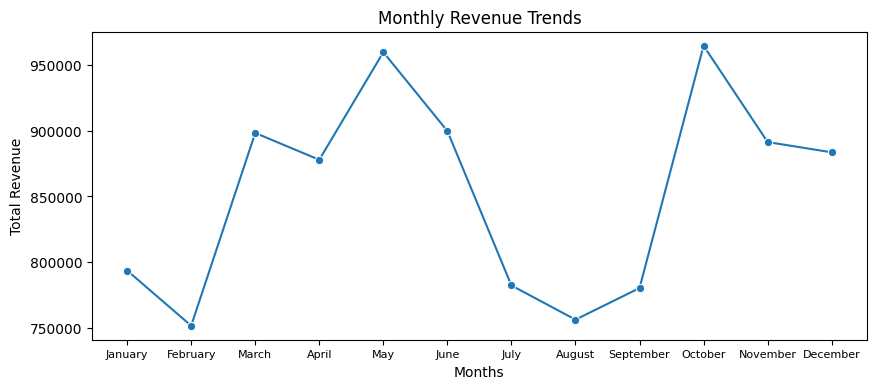

In [202]:
# Group data by month and analyse monthly revenue

non_zero_df['tpep_pickup_month'] = non_zero_df['tpep_pickup_datetime'].dt.month_name()
monthly_ta_trends = (non_zero_df.groupby('tpep_pickup_month')['total_amount'].sum()
                        .reset_index(name='monthly_revenue'))

# Convert to categorical with proper order
monthly_ta_trends['tpep_pickup_month'] = pd.Categorical(
    monthly_ta_trends['tpep_pickup_month'],
    categories=month_order,
    ordered=True
)

# Sort dataframe
monthly_ta_trends = monthly_ta_trends.sort_values(
    'tpep_pickup_month'
)
print(monthly_ta_trends)

# Plot
plt.figure(figsize=(10,4))

sns.lineplot(
    data=monthly_ta_trends,
    x='tpep_pickup_month',
    y='monthly_revenue',
    marker='o'
)

plt.title('Monthly Revenue Trends')
plt.xlabel('Months')
plt.ylabel('Total Revenue')
plt.xticks(range(12), fontsize=8)

plt.show()

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

   quarter  qtr_revenue
0        1   2443245.22
1        2   2737838.25
2        3   2318164.75
3        4   2740080.89


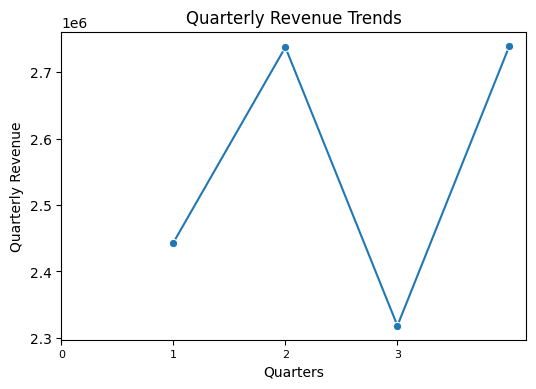

In [206]:
# Calculate proportion of each quarter

non_zero_df['quarter'] = non_zero_df['tpep_pickup_datetime'].dt.quarter

qtr_revenue = (non_zero_df.groupby('quarter')['total_amount'].sum().reset_index(name='qtr_revenue')).sort_values('quarter')
print(qtr_revenue)

# Plot
plt.figure(figsize=(6,4))

sns.lineplot(
    data=qtr_revenue,
    x='quarter',
    y='qtr_revenue',
    marker='o'
)

plt.title('Quarterly Revenue Trends')
plt.xlabel('Quarters')
plt.ylabel('Quarterly Revenue')
plt.xticks(range(4), fontsize=8)

plt.show()

**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

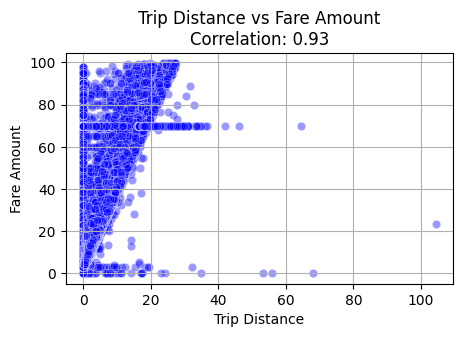

In [207]:
# Show how trip fare is affected by distance

corr = non_zero_df['trip_distance'].corr(non_zero_df['fare_amount'])

plt.figure(figsize=(5, 3))

sns.scatterplot(
    data=non_zero_df,
    x='trip_distance',
    y='fare_amount',
    color='blue',
    alpha=0.4
)

plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")
plt.title(f"Trip Distance vs Fare Amount\nCorrelation: {corr:.2f}")
plt.grid(True)
plt.show()

**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

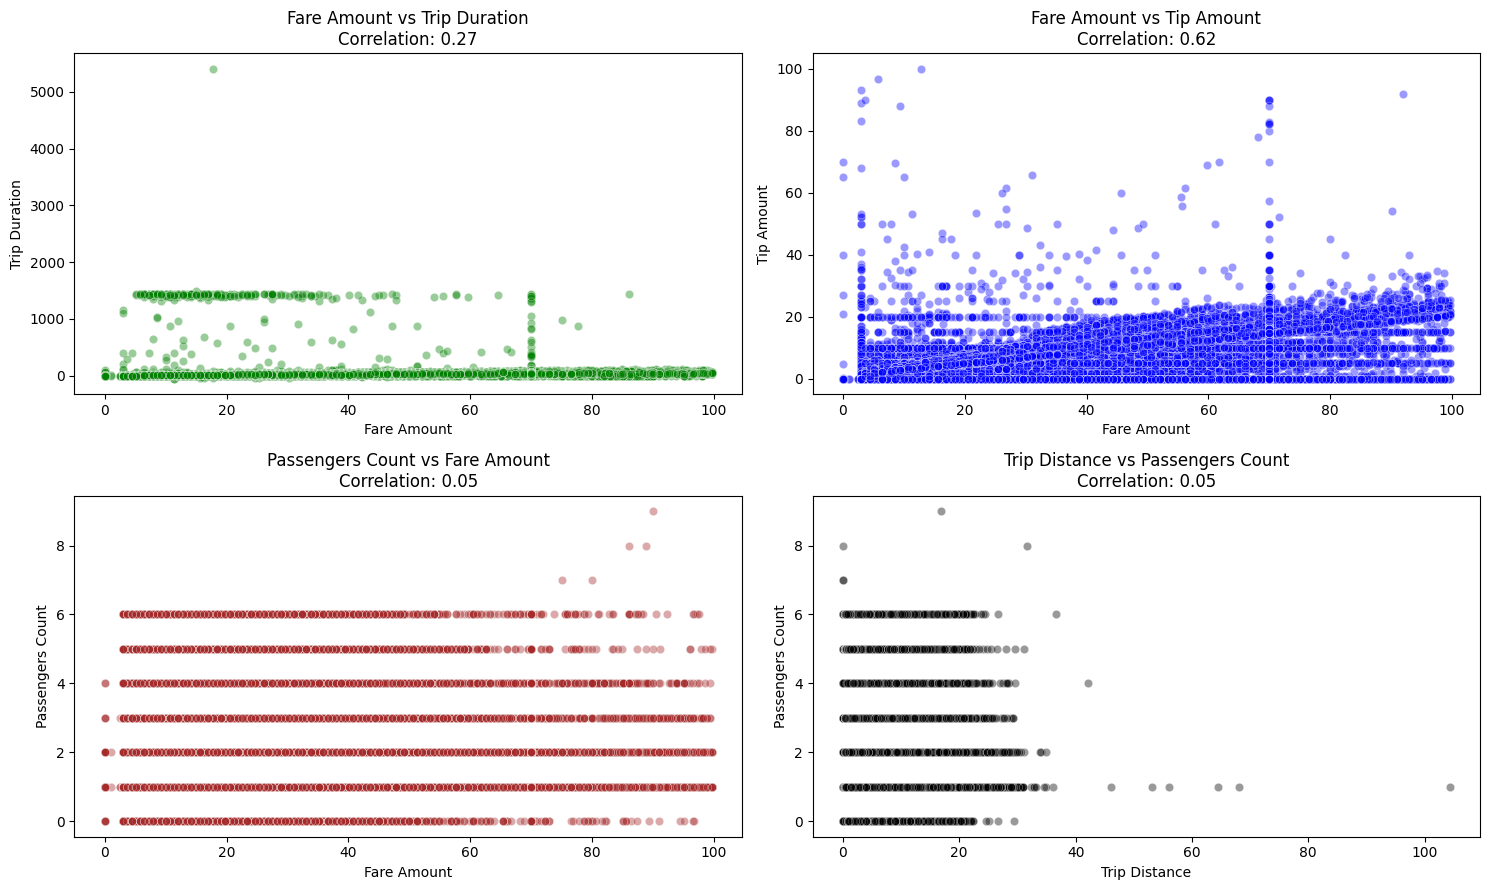

In [242]:
# Show relationship between fare and trip duration

corr1 = non_zero_df['trip_duration_mins'].corr(non_zero_df['fare_amount'])
corr2 = non_zero_df['fare_amount'].corr(non_zero_df['tip_amount'])
corr3 = non_zero_df['fare_amount'].corr(non_zero_df['passenger_count'])
corr4 = non_zero_df['trip_distance'].corr(non_zero_df['passenger_count'])

fig, axes = plt.subplots(2, 2, figsize=(15,9))
axes = axes.ravel()

sns.scatterplot(
    data=non_zero_df,
    x='fare_amount',
    y='trip_duration_mins',
    ax=axes[0],
    color='green',
    alpha=0.4
)
axes[0].set_xlabel("Fare Amount")
axes[0].set_ylabel("Trip Duration")
axes[0].set_title(f"Fare Amount vs Trip Duration\nCorrelation: {corr1:.2f}")

sns.scatterplot(
    data=non_zero_df,
    x='fare_amount',
    y='tip_amount',
    ax=axes[1],
    color='blue',
    alpha=0.4
)
axes[1].set_xlabel("Fare Amount")
axes[1].set_ylabel("Tip Amount")
axes[1].set_title(f"Fare Amount vs Tip Amount\nCorrelation: {corr2:.2f}")

sns.scatterplot(
    data=non_zero_df,
    x='fare_amount',
    y='passenger_count',
    ax=axes[2],
    color='brown',
    alpha=0.4
)
axes[2].set_xlabel("Fare Amount")
axes[2].set_ylabel("Passengers Count")
axes[2].set_title(f"Passengers Count vs Fare Amount\nCorrelation: {corr3:.2f}")

sns.scatterplot(
    data=non_zero_df,
    x='trip_distance',
    y='passenger_count',
    ax=axes[3],
    color='black',
    alpha=0.4
)
axes[3].set_xlabel("Trip Distance")
axes[3].set_ylabel("Passengers Count")
axes[3].set_title(f"Trip Distance vs Passengers Count\nCorrelation: {corr3:.2f}")

plt.tight_layout()
plt.show()

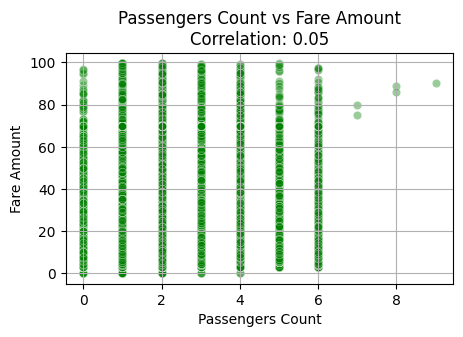

In [243]:
# Show relationship between fare and number of passengers

corr = non_zero_df['passenger_count'].corr(non_zero_df['fare_amount'])

plt.figure(figsize=(5, 3))

sns.scatterplot(
    data=non_zero_df,
    x='passenger_count',
    y='fare_amount',
    color='green',
    alpha=0.4
)

plt.xlabel("Passengers Count")
plt.ylabel("Fare Amount")
plt.title(f"Passengers Count vs Fare Amount\nCorrelation: {corr:.2f}")
plt.grid(True)
plt.show()

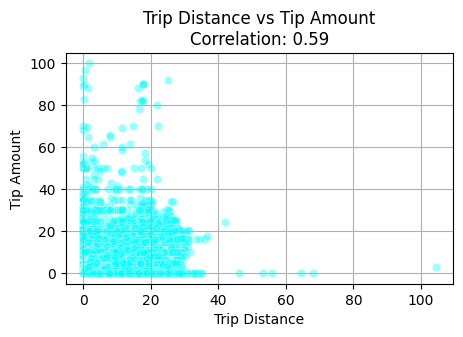

In [244]:
# Show relationship between tip and trip distance

corr = non_zero_df['trip_distance'].corr(non_zero_df['tip_amount'])

plt.figure(figsize=(5, 3))

sns.scatterplot(
    data=non_zero_df,
    x='trip_distance',
    y='tip_amount',
    color='cyan',
    alpha=0.4
)

plt.xlabel("Trip Distance")
plt.ylabel("Tip Amount")
plt.title(f"Trip Distance vs Tip Amount\nCorrelation: {corr:.2f}")
plt.grid(True)
plt.show()

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

  payment_type_name  dist_count
0              Cash       62947
1       Credit Card      295542
2           Dispute        2699
3         No Charge        1728


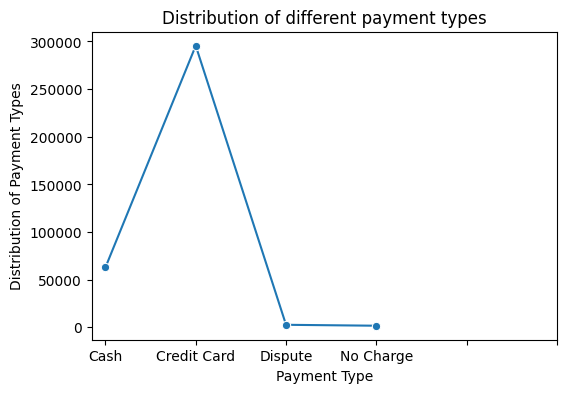

In [258]:
# Analyse the distribution of different payment types (payment_type).

payment_type_map = {
    1: 'Credit Card',
    2: 'Cash',
    3: 'No Charge',
    4: 'Dispute',
    5: 'Unknown',
    6: 'Voided Trip'
}

non_zero_df['payment_type_name'] = (non_zero_df['payment_type'].map(payment_type_map))

payment_type_df = (non_zero_df.groupby('payment_type_name').size().reset_index(name='dist_count')).sort_values('payment_type_name')

print(payment_type_df)

# Plot
plt.figure(figsize=(6,4))

sns.lineplot(
    data=payment_type_df,
    x='payment_type_name',
    y='dist_count',
    marker='o'
)

plt.title('Distribution of different payment types')
plt.xlabel('Payment Type')
plt.ylabel('Distribution of Payment Types')
plt.xticks(range(6))

plt.show()

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [251]:
# !pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [284]:
import geopandas as gpd


# Read the shapefile using geopandas
zones = gpd.read_file('trip_zones/taxi_zones.shp')
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    str     
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    str     
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), str(2)
memory usage: 12.5 KB
None


<Axes: >

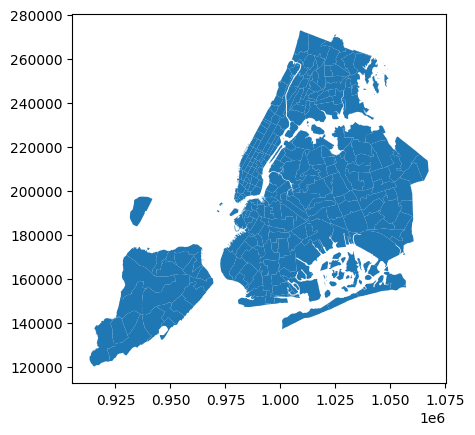

In [270]:
print(zones.info())
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [297]:
# Merge zones and trip records using locationID and PULocationID

merged_df = non_zero_df.merge(
    zones,
    left_on='PULocationID',
    right_on='LocationID',
    how='inner'
)

# Preview
merged_df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tpep_pickup_month,payment_type_name,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,...,January,Cash,138,0.107467,0.000537,LaGuardia Airport,138,Queens,"MULTIPOLYGON (((1019904.219 225677.983, 102031...",12576.0
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,January,Credit Card,161,0.035804,0.000072,Midtown Center,161,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21...",17101.0
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,...,January,Cash,237,0.042213,0.000096,Upper East Side South,237,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21...",17340.0
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,...,January,Cash,143,0.054180,0.000151,Lincoln Square West,143,Manhattan,"POLYGON ((989338.1 223572.253, 989368.225 2235...",3931.0
4,1,2023-01-01 00:42:56,2023-01-01 01:16:33,2.0,7.10,1.0,N,246,37,1,...,January,Credit Card,246,0.069467,0.000281,West Chelsea/Hudson Yards,246,Manhattan,"POLYGON ((983031.177 217138.506, 983640.32 216...",6112.0


In [298]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 359368 entries, 0 to 359367
Data columns (total 32 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               359368 non-null  int64         
 1   tpep_pickup_datetime   359368 non-null  datetime64[us]
 2   tpep_dropoff_datetime  359368 non-null  datetime64[us]
 3   passenger_count        359368 non-null  float64       
 4   trip_distance          359368 non-null  float64       
 5   RatecodeID             359368 non-null  float64       
 6   store_and_fwd_flag     359368 non-null  object        
 7   PULocationID           359368 non-null  int64         
 8   DOLocationID           359368 non-null  int64         
 9   payment_type           359368 non-null  int64         
 10  fare_amount            359368 non-null  float64       
 11  extra                  359368 non-null  float64       
 12  mta_tax                359368 non-null  float64       


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [286]:
# Group data by location and calculate the number of trips

trip_counts_by_loc = ( merged_df.groupby('LocationID').size().reset_index(name='trip_count') )

# Preview
trip_counts_by_loc.head()

,LocationID,trip_count
0,1,23
1,3,2
2,4,353
3,6,4
4,7,148


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [287]:
# Merge trip counts back to the zones GeoDataFrame

zones = zones.merge( trip_counts_by_loc[ ['LocationID', 'trip_count'] ], on='LocationID', how='left' )

# For given location id, fill missing values with 0 
zones['trip_count'] = ( zones['trip_count'].fillna(0) )

# Preview
zones[ zones['LocationID']==7 ].head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count
6,7,0.107417,0.00039,Astoria,7,Queens,"POLYGON ((1010804.218 218919.641, 1011049.165 ...",148.0


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

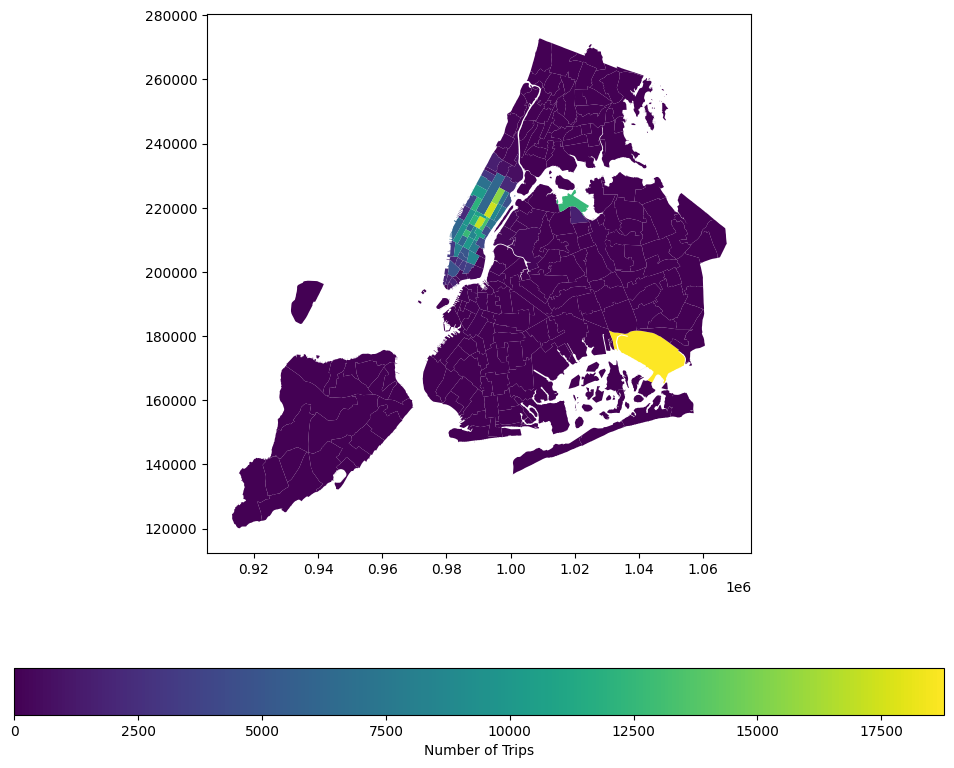

In [275]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize = (12, 10))

# Plot the map and display it

zones.plot(
    column='trip_count',
    ax=ax,
    legend=True,
    legend_kwds={
        'label': 'Number of Trips',
        'orientation': 'horizontal'
    }
)

plt.show()

In [290]:
# can you try displaying the zones DF sorted by the number of trips?

sorted_df = zones.sort_values( 'trip_count', ascending=False)

sorted_df.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,trip_count
131,132,0.245479,0.002038,JFK Airport,132,Queens,"MULTIPOLYGON (((1032791.001 181085.006, 103283...",18774.0
236,237,0.042213,0.000096,Upper East Side South,237,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21...",17340.0
160,161,0.035804,0.000072,Midtown Center,161,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21...",17101.0
235,236,0.044252,0.000103,Upper East Side North,236,Manhattan,"POLYGON ((995940.048 221122.92, 995812.322 220...",15511.0
161,162,0.035270,0.000048,Midtown East,162,Manhattan,"POLYGON ((992224.354 214415.293, 992096.999 21...",13206.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [313]:
# Find routes which have the slowest speeds at different times of the day

# Let's look at route of diff zones
route_df = merged_df[ merged_df['PULocationID'] != merged_df['DOLocationID'] ].copy()

# Group by pickup zone, dropoff zone, and pickup hour
route_speed_df = ( route_df.groupby(
        [
            'PULocationID',
            'DOLocationID',
            'tpep_pickup_hour'
        ]
    )
    .agg(
        avg_trip_distance=('trip_distance', 'mean'),
        avg_trip_duration_mins=('trip_duration_mins', 'mean')
    )
    .reset_index()
)

# Let us calculate speed for particular hour, converting mins to hour
route_speed_df['avg_speed_per_hr'] = ( route_speed_df['avg_trip_distance'] / (route_speed_df['avg_trip_duration_mins'] / 60) )
# Let's keep only data where the value avg_speed_per_hr > 0
route_speed_df = route_speed_df[ route_speed_df['avg_speed_per_hr'] > 0 ]

# Now let us find slowest routes at each hour
slowest_routes = ( route_speed_df.sort_values( ['tpep_pickup_hour', 'avg_speed_per_hr']  ).groupby('tpep_pickup_hour').head(1) )

# Display results
slowest_routes[
    [
        'tpep_pickup_hour',
        'PULocationID',
        'DOLocationID',
        'avg_trip_distance',
        'avg_trip_duration_mins',
        'avg_speed_per_hr'
    ]
]

,tpep_pickup_hour,PULocationID,DOLocationID,avg_trip_distance,avg_trip_duration_mins,avg_speed_per_hr
12881,0,88,144,1.780000,1425.466667,0.074923
59131,1,238,249,4.580000,1396.200000,0.196820
63183,2,255,256,0.010000,4.250000,0.141176
34886,3,148,238,6.040000,1429.983333,0.253430
50240,4,230,51,16.960000,1417.666667,0.717799
63352,5,261,14,10.530000,1117.466667,0.565386
8602,6,70,138,1.490000,1042.566667,0.085750
38224,7,161,238,2.810000,705.600000,0.238946
5581,8,50,43,1.420000,1431.333333,0.059525
31460,9,142,232,6.710000,1411.400000,0.285249


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

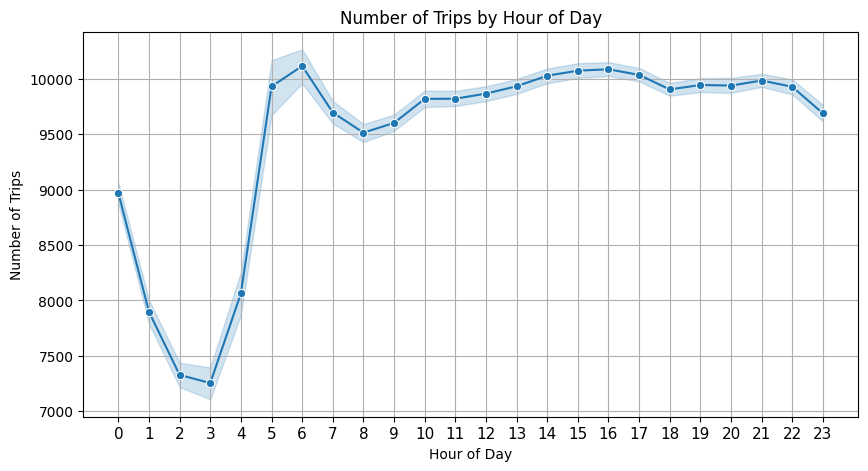

In [317]:
# Visualise the number of trips per hour and find the busiest hour

# Plot
plt.figure(figsize=(10,5))

sns.lineplot(
    data=merged_df,
    x='tpep_pickup_hour',
    y='trip_count',
    marker='o'
)

plt.title( 'Number of Trips by Hour of Day')

plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(ticks=range(24), labels=range(24), fontsize=11)
plt.grid(True)
plt.show()

Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

#### Please note that in my case, data is taken as 1% of the original data, hence 

<b>Actual Count = Sample Count / Sampling Fraction</b>

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [339]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.01

merged_df['actual_est_count'] = merged_df['trip_count'] / sample_fraction

# Calculate total trips by hour
hour_count_df = (merged_df.groupby('tpep_pickup_hour')['actual_est_count']
                     .sum()
                     .reset_index(name='actual_est_count')
                )
hour_count_df = hour_count_df.sort_values('actual_est_count', ascending=False)

hour_count_df.head(5)

,tpep_pickup_hour,actual_est_count
18,18,25467
17,17,24339
19,19,22864
15,15,22459
16,16,22427


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

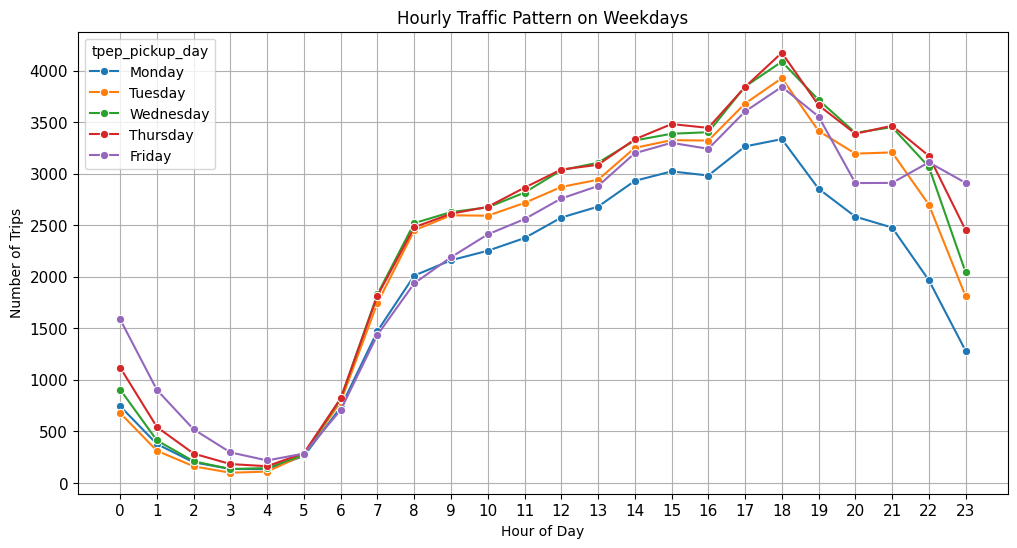

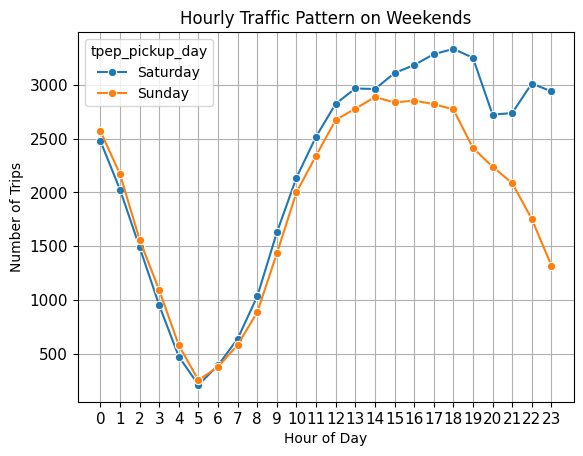

In [351]:
# Compare traffic trends for the week days and weekends

weekdays = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday'
]

weekend = [ 'Saturday', 'Sunday' ]

weekdays_df = merged_df[ merged_df['tpep_pickup_day'].isin(weekdays) ]
weekend_df = merged_df[ merged_df['tpep_pickup_day'].isin(weekend) ]

weekdays_hourly_df = (  weekdays_df.groupby( ['tpep_pickup_day', 'tpep_pickup_hour'] ).size().reset_index(name='trip_count') )
weekend_hourly_df = (  weekend_df.groupby( ['tpep_pickup_day', 'tpep_pickup_hour'] ).size().reset_index(name='trip_count') )

# sort out weekday order
weekdays_hourly_df['tpep_pickup_day'] = pd.Categorical( weekdays_hourly_df['tpep_pickup_day'], categories=weekdays, ordered=True)
weekend_hourly_df['tpep_pickup_day'] = pd.Categorical( weekend_hourly_df['tpep_pickup_day'], categories=weekend, ordered=True)

# Plot
plt.figure(figsize=(12,6))

sns.lineplot(
    data=weekdays_hourly_df,
    x='tpep_pickup_hour',
    y='trip_count',
    hue='tpep_pickup_day',
    marker='o'
)

plt.title( 'Hourly Traffic Pattern on Weekdays')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(
    ticks=range(24),
    labels=range(24),
    fontsize=11
)
plt.yticks(fontsize=11)
plt.grid(True)
plt.show()

# Visual for weekend trips
sns.lineplot(
    data=weekend_hourly_df,
    x='tpep_pickup_hour',
    y='trip_count',
    hue='tpep_pickup_day',
    marker='o'
)

plt.title( 'Hourly Traffic Pattern on Weekends')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')
plt.xticks(
    ticks=range(24),
    labels=range(24),
    fontsize=11
)
plt.yticks(fontsize=11)
plt.grid(True)
plt.show()

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [370]:
# top 10 zones with high hourly pickups.
top10_pickup_zones = (
    merged_df.groupby(
        [
            'tpep_pickup_hour',
            'PULocationID',
            'zone',
            'borough'
        ]
    )
    .size()
    .reset_index(name='pickup_count')
    .sort_values(
        ['pickup_count'],
        ascending=[False]
    )
)

top10_pickup_zones.head(10)

,tpep_pickup_hour,PULocationID,zone,borough,pickup_count
2077,18,161,Midtown Center,Manhattan,1500
1963,17,161,Midtown Center,Manhattan,1479
1997,17,237,Upper East Side South,Manhattan,1360
2510,22,132,JFK Airport,Queens,1335
1751,15,237,Upper East Side South,Manhattan,1333
1692,15,132,JFK Airport,Queens,1330
1841,16,161,Midtown Center,Manhattan,1323
2191,19,161,Midtown Center,Manhattan,1320
1750,15,236,Upper East Side North,Manhattan,1300
2112,18,237,Upper East Side South,Manhattan,1289


In [372]:
merged_df['tpep_dropoff_hour'] = ( merged_df['tpep_dropoff_datetime'].dt.hour )

# top 10 zones with high hourly dropoffs.
top10_dropoff_zones = (
    merged_df.groupby(
        [
            'tpep_dropoff_hour',
            'DOLocationID',
            'zone',
            'borough'
        ]
    )
    .size()
    .reset_index(name='dropoff_count')
    .sort_values(
        ['dropoff_count'],
        ascending=[False]
    )
)

top10_dropoff_zones.head(10)

,tpep_dropoff_hour,DOLocationID,zone,borough,dropoff_count
38623,15,236,Upper East Side South,Manhattan,230
41955,16,236,Upper East Side South,Manhattan,230
45405,17,236,Upper East Side South,Manhattan,216
48943,18,236,Upper East Side South,Manhattan,206
28987,12,237,Upper East Side North,Manhattan,204
48995,18,237,Upper East Side North,Manhattan,197
32116,13,236,Upper East Side South,Manhattan,192
32166,13,237,Upper East Side North,Manhattan,182
38672,15,237,Upper East Side North,Manhattan,180
35308,14,236,Upper East Side South,Manhattan,180


**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [397]:
# Find the top 10 and bottom 10 pickup/dropoff ratios

# Pickup counts per zone
pickup_counts = (
    merged_df.groupby(
        ['PULocationID', 'zone', 'borough', 'tpep_pickup_hour']
    )
    .size()
    .reset_index(name='pickup_count')
)

# Dropoff counts per zone
dropoff_counts = (
    merged_df.groupby(
        ['DOLocationID', 'zone', 'borough', 'tpep_dropoff_hour']
    )
    .size()
    .reset_index(name='dropoff_count')
)

zone_counts_df = pickup_counts.merge(
    dropoff_counts,
    on='zone',
    how='outer'
)
# Fill missing values
zone_counts_df[ ['pickup_count', 'dropoff_count'] ] = zone_counts_df[ ['pickup_count', 'dropoff_count'] ].fillna(0)

# Calc the ratio
zone_counts_df['pickup_dropoff_ratio'] = np.where( zone_counts_df['dropoff_count'] > 0, 
                                                   zone_counts_df['pickup_count'] / zone_counts_df['dropoff_count'],
                                                   np.nan
                                        )

zone_counts_df.head()

,PULocationID,zone,borough_x,tpep_pickup_hour,pickup_count,DOLocationID,borough_y,tpep_dropoff_hour,dropoff_count,pickup_dropoff_ratio
0,3,Allerton/Pelham Gardens,Bronx,8,1,3,Bronx,22,1,1.0
1,3,Allerton/Pelham Gardens,Bronx,8,1,237,Bronx,9,1,1.0
2,3,Allerton/Pelham Gardens,Bronx,22,1,3,Bronx,22,1,1.0
3,3,Allerton/Pelham Gardens,Bronx,22,1,237,Bronx,9,1,1.0
4,4,Alphabet City,Manhattan,0,39,4,Manhattan,0,1,39.0


In [391]:
# Top 10 ratio

max_ratio_df = (
    zone_counts_df.groupby('zone')['pickup_dropoff_ratio']
                   .max()
                   .reset_index()
                   .sort_values(
                       'pickup_dropoff_ratio',
                       ascending=False
                   )
)

# Top 10 zones with high pickups ratio
max_ratio_df.head(10)

,zone,pickup_dropoff_ratio
102,JFK Airport,18774.0
198,Upper East Side South,17340.0
131,Midtown Center,17101.0
197,Upper East Side North,15511.0
132,Midtown East,13206.0
153,Penn Station/Madison Sq West,12655.0
111,LaGuardia Airport,12576.0
191,Times Sq/Theatre District,12122.0
114,Lincoln Square East,12067.0
140,Murray Hill,10808.0


In [392]:
# Bottom 10 ratio

min_ratio_df = (
    zone_counts_df.groupby('zone')['pickup_dropoff_ratio']
                   .min()
                   .reset_index()
                   .sort_values(
                       'pickup_dropoff_ratio',
                       ascending=True
                   )
)

# Bottom 10 zones with high pickups ratio
min_ratio_df.head(10)

,zone,pickup_dropoff_ratio
21,Bronx Park,1.0
22,Bronxdale,1.0
50,Cypress Hills,1.0
36,City Island,1.0
52,Douglaston,1.0
84,Glendale,1.0
78,Fordham South,1.0
70,Far Rockaway,1.0
82,Fresh Meadows,1.0
99,Hunts Point,1.0


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [413]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones

night_hrs_df = merged_df[
    (
        (merged_df['tpep_pickup_hour'] >= 23) | (merged_df['tpep_pickup_hour'] <= 5)
    )
]

# pickup zones for each night hour
pickup_night = (
                    night_hrs_df.groupby( ['tpep_pickup_hour', 'zone'] )
                   .size()
                   .reset_index(name='pickup_count')
                   .sort_values(
                    ['tpep_pickup_hour', 'pickup_count'],
                    ascending=[True, False]
                    )
)

max_count_df = (
    pickup_night.groupby( ['zone'] )['pickup_count']
                   .max()
                   .reset_index()
                   .sort_values(
                       'pickup_count',
                       ascending=False
                   )
)

# Top 10 pickup zones for each night hour
max_count_df.head(10)

,zone,pickup_count
74,JFK Airport,1227
83,LaGuardia Airport,795
48,East Village,727
159,West Village,665
86,Lincoln Square East,605
143,Times Sq/Theatre District,603
27,Clinton East,594
100,Midtown Center,569
117,Penn Station/Madison Sq West,546
91,Lower East Side,477


In [414]:
night_hrs_df = merged_df[
    (
        (merged_df['tpep_dropoff_hour'] >= 23) | (merged_df['tpep_dropoff_hour'] <= 5)
    )
]

# pickup zones for each night hour
pickup_night = (
                    night_hrs_df.groupby( ['tpep_dropoff_hour', 'zone'] )
                   .size()
                   .reset_index(name='dropoff_count')
                   .sort_values(
                    ['tpep_dropoff_hour', 'dropoff_count'],
                    ascending=[True, False]
                    )
)

max_count_df = (
    pickup_night.groupby( ['zone'] )['dropoff_count']
                   .max()
                   .reset_index()
                   .sort_values(
                       'dropoff_count',
                       ascending=False
                   )
)

# Top 10 pickup zones for each night hour
max_count_df.head(10)

,zone,dropoff_count
72,JFK Airport,1365
81,LaGuardia Airport,772
46,East Village,742
156,West Village,688
141,Times Sq/Theatre District,679
84,Lincoln Square East,679
27,Clinton East,642
98,Midtown Center,629
115,Penn Station/Madison Sq West,552
89,Lower East Side,465


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [422]:
# Filter for night hours (11 PM to 5 AM)

night_hrs_df = merged_df[
    (
        (merged_df['tpep_pickup_hour'] >= 23) | (merged_df['tpep_pickup_hour'] <= 5)
    )
]

day_hrs_df = merged_df[
    (
        (merged_df['tpep_pickup_hour'] > 5) | (merged_df['tpep_pickup_hour'] < 23)
    )
]

night_revenue = night_hrs_df['total_amount'].sum()
day_revenue = day_hrs_df['total_amount'].sum()

print("Total night revenue", night_revenue)
print("Total day revenue", day_revenue)

Total night revenue 1225387.28
Total day revenue 10133545.52


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [427]:
# Analyse the fare per mile per passenger for different passenger counts

# Avoid divide-by-zero issues
filtered_df = merged_df[
    (merged_df['trip_distance'] > 0) &
    (merged_df['passenger_count'] > 0)
]

# Average fare per mile by passenger count
avg_fare_per_mile_per_passenger = (
    filtered_df.groupby([ 'trip_distance', 'passenger_count'])
            .agg(
                avg_fare_per_mile=('fare_per_mile', 'mean'),
                avg_trip_distance=('trip_distance', 'mean'),
                avg_fare_amount=('fare_amount', 'mean'),
                total_fare_amount=('fare_amount', 'sum'),
            )
            .reset_index()
            .sort_values('passenger_count')
)

avg_fare_per_mile_per_passenger


KeyError: "Label(s) ['fare_per_mile'] do not exist"

In [426]:
# Remove invalid/zero trip distances
valid_df = df[
    df['trip_distance'] > 0
]

# Calculate fare per mile
valid_df['fare_per_mile'] = (
    valid_df['fare_amount'] /
    valid_df['trip_distance']
)



,trip_distance,passenger_count,avg_fare_per_mile,avg_trip_distance,avg_fare_amount,total_fare_amount
0,0.01,0.0,1600.000000,0.01,16.000000,16.0
43,0.10,0.0,43.058824,0.10,4.305882,73.2
9886,29.50,0.0,2.372881,29.50,70.000000,70.0
2877,4.90,0.0,5.551020,4.90,27.200000,380.8
2769,4.70,0.0,5.351690,4.70,25.152941,427.6
...,...,...,...,...,...,...
8003,18.10,6.0,4.483425,18.10,81.150000,162.3
2802,4.75,6.0,5.863158,4.75,27.850000,55.7
9924,36.67,6.0,1.908917,36.67,70.000000,70.0
9913,31.71,8.0,2.803532,31.71,88.900000,88.9


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [ ]:
# Compare the average fare per mile for different days and for different times of the day



**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

In [ ]:
# Compare fare per mile for different vendors



**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [ ]:
# Defining distance tiers



##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [ ]:
#  Analyze tip percentages based on distances, passenger counts and pickup times



Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [ ]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%



**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

In [ ]:
# See how passenger count varies across hours and days




**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [ ]:
# How does passenger count vary across zones



In [ ]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.



Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [ ]:
# How often is each surcharge applied?



## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.